In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

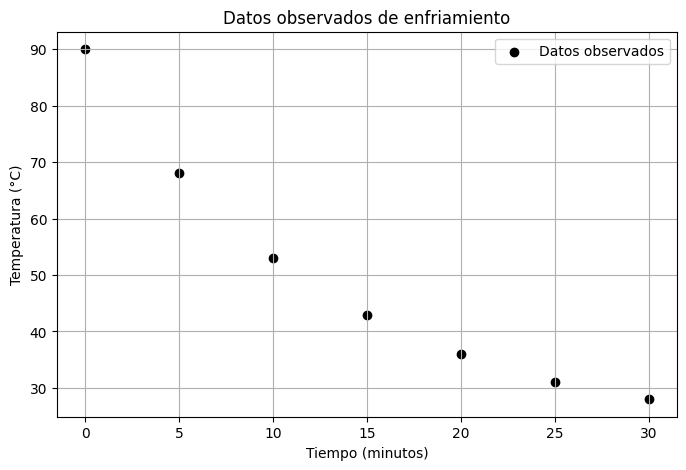

In [51]:
datos = {
    "tiempo": [0, 5, 10, 15, 20, 25, 30],
    "temperatura_observada": [90, 68, 53, 43, 36, 31, 28]
}

df_obs = pd.DataFrame(datos)

df_obs

plt.figure(figsize=(8, 5))

plt.scatter(
    df_obs["tiempo"],
    df_obs["temperatura_observada"],
    label = "Datos observados",
    color = 'black'
)

plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.title("Datos observados de enfriamiento")
plt.legend()
plt.grid()

plt.show()

In [52]:
datos_observados = [0, 950, 1800, 2650, 3400, 4100, 4800, 5400, 5900, 6350, 6750, 7100, 7400]
df_obs = pd.DataFrame({
    "semana": np.arange(0, t + 1),
    "valor_observado": datos_observados  # antes decía temperatura, ahora coincide con tu tema
})

In [53]:
def modelo_saturacion(L, k, t):
    tiempos = np.arange(0, t + 1)
    # Cálculo del modelo
    U_t = L * (1 - np.exp(-k * tiempos))
    datos_observados = [0, 950, 1800, 2650, 3400, 4100, 4800, 5400, 5900, 6350, 6750, 7100, 7400]
    # DataFrame
    df_modelo = pd.DataFrame({
        "semana": tiempos,
        "usuarios_estimados": U_t,
        "datos_observados": datos_observados
    })

    return df_modelo

In [54]:

L=10000
k=0.10
t=12
df_modelo = modelo_saturacion(L, k , t)
df_modelo



,semana,usuarios_estimados,datos_observados
0,0,0.000000,0
1,1,951.625820,950
2,2,1812.692469,1800
3,3,2591.817793,2650
4,4,3296.799540,3400
5,5,3934.693403,4100
6,6,4511.883639,4800
7,7,5034.146962,5400
8,8,5506.710359,5900
9,9,5934.303403,6350


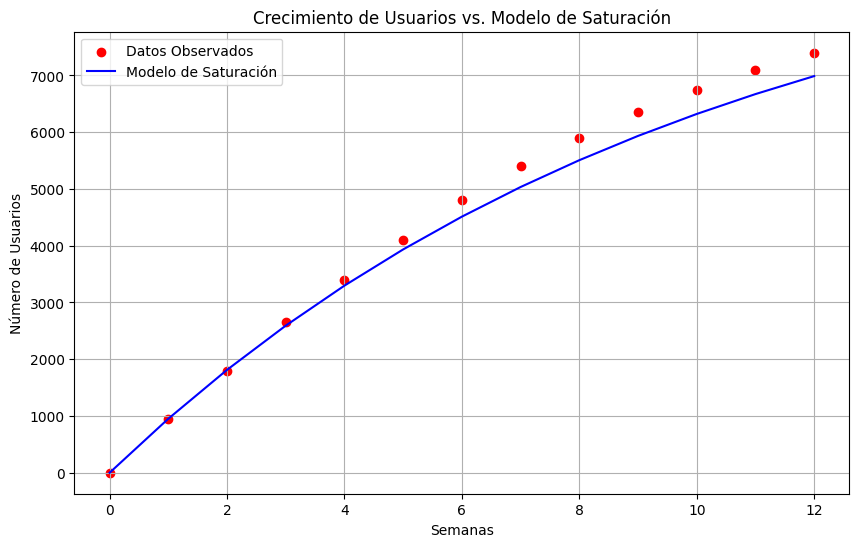

In [55]:

plt.figure(figsize=(10, 6))
plt.scatter(df_modelo['semana'], df_modelo['datos_observados'], color='red', label='Datos Observados')
plt.plot(df_modelo['semana'], df_modelo['usuarios_estimados'], color='blue', label='Modelo de Saturación')

plt.title('Crecimiento de Usuarios vs. Modelo de Saturación')
plt.xlabel('Semanas')
plt.ylabel('Número de Usuarios')
plt.grid()
plt.legend()
plt.show()

Como se puede observar cuando k=0.10 no se ajusta de la mejor manera ya que mientras va pasando la semana el modelo presenta un presicion mas baja ejemplo en la semana uno puede haber una persona de mas pero en la semana 12 en modelo se atrasa por mas de 400 personas.

In [56]:
df_comparacion = pd.merge(df_obs, df_modelo, on="semana")
df_comparacion["error"] = (
    df_comparacion["valor_observado"]
    - df_comparacion["usuarios_estimados"]
)

df_comparacion["error_absoluto"] = np.abs(df_comparacion["error"])
df_comparacion["error_cuadratico"] = df_comparacion["error"]**2

df_comparacion

,semana,valor_observado,usuarios_estimados,datos_observados,error,error_absoluto,error_cuadratico
0,0,0,0.000000,0,0.000000,0.000000,0.000000
1,1,950,951.625820,950,-1.625820,1.625820,2.643290
2,2,1800,1812.692469,1800,-12.692469,12.692469,161.098775
3,3,2650,2591.817793,2650,58.182207,58.182207,3385.169190
4,4,3400,3296.799540,3400,103.200460,103.200460,10650.335018
5,5,4100,3934.693403,4100,165.306597,165.306597,27326.271053
6,6,4800,4511.883639,4800,288.116361,288.116361,83011.037441
7,7,5400,5034.146962,5400,365.853038,365.853038,133848.445351
8,8,5900,5506.710359,5900,393.289641,393.289641,154676.741853
9,9,6350,5934.303403,6350,415.696597,415.696597,172803.661095


In [57]:
mae = df_comparacion["error_absoluto"].mean()
mse = df_comparacion["error_cuadratico"].mean()
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 236.41619680079197
MSE: 86401.48783350295
RMSE: 293.94129997926956


¿El error es grande o pequeño en comparación con el número de usuarios? a pesar de que el modelo se queda atras por 411 persona esta equivale a menos de 6% de error por lo que no teniendo factores externos se podria decir que es un buen modelo

In [73]:
valores_k = np.arange(0.05, 0.21, 0.01)

resultados = []

for k in valores_k:
    df_modelo = modelo_saturacion(L, k, t)

    df_comparacion = pd.merge(df_obs, df_modelo, on="semana")

    error = (
        df_comparacion["valor_observado"]
      - df_comparacion["usuarios_estimados"]
    )

    mae = np.mean(np.abs(error))
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)

    resultados.append({
        "k": k,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,k,MAE,MSE,RMSE
0,0.05,1892.348438,4.474736e+06,2115.357181
1,0.06,1507.747139,2.838736e+06,1684.855018
2,0.07,1151.993159,1.663378e+06,1289.719949
3,0.08,822.614598,8.591672e+05,926.912712
4,0.09,517.367401,3.532710e+05,594.366071
5,0.10,236.416197,8.640149e+04,293.941300
6,0.11,86.509310,1.029522e+04,101.465372
7,0.12,273.055296,8.566650e+04,292.688404
8,0.13,500.385492,2.805452e+05,529.665220
9,0.14,712.084116,5.689263e+05,754.272061


¿Qué significa que un valor de (k) tenga menor RMSE que otro?  que el error promedio es menor

¿El modelo mejora respecto al caso inicial k=10?no en ambos caso me sale el mismo error

In [74]:
mejor = df_resultados.loc[df_resultados["RMSE"].idxmin()]

print("Mejor valor encontrado:")
print(mejor)

Mejor valor encontrado:
k           0.110000
MAE        86.509310
MSE     10295.221654
RMSE      101.465372
Name: 6, dtype: float64


In [60]:

k_mejor = mejor["k"]

print("k óptimo aproximado:", k_mejor)

k óptimo aproximado: 0.11


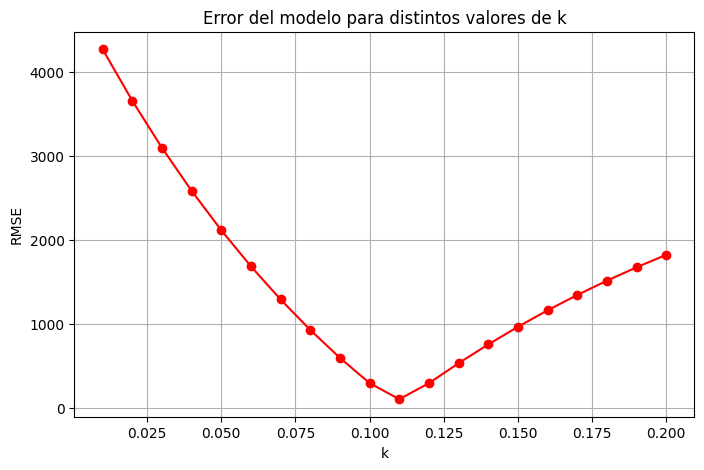

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(df_resultados["k"], df_resultados["RMSE"],
         marker="o", color  = 'red')

plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("Error del modelo para distintos valores de k")
plt.grid()

plt.show()

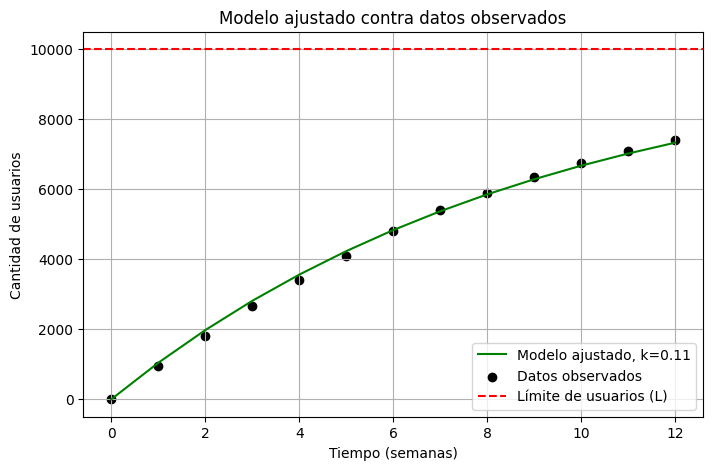

In [62]:
df_modelo_mejor = modelo_saturacion(L, k_mejor, t)

plt.figure(figsize=(8, 5))

plt.plot(
    df_modelo_mejor["semana"],
    df_modelo_mejor["usuarios_estimados"],
    label=f"Modelo ajustado, k={k_mejor:.2f}",
    color='green'
)

plt.scatter(
    df_obs["semana"],
    df_obs["valor_observado"],
    label="Datos observados",
    color='black'
)
plt.axhline(y=L, linestyle="--", color='red', label="Límite de usuarios (L)")
plt.xlabel("Tiempo (semanas)")
plt.ylabel("Cantidad de usuarios")
plt.title("Modelo ajustado contra datos observados")
plt.legend()
plt.grid()

plt.show()

In [63]:
df_final = pd.merge(df_obs, df_modelo_mejor, on="semana")

df_final["error"] = (
    df_final["valor_observado"]
    - df_final["usuarios_estimados"]
)

df_final["error_absoluto"] = np.abs(df_final["error"])

df_final

,semana,valor_observado,usuarios_estimados,datos_observados,error,error_absoluto
0,0,0,0.000000,0,0.000000,0.000000
1,1,950,1041.658647,950,-91.658647,91.658647
2,2,1800,1974.812020,1800,-174.812020,174.812020
3,3,2650,2810.762666,2650,-160.762666,160.762666
4,4,3400,3559.635789,3400,-159.635789,159.635789
5,5,4100,4230.501896,4100,-130.501896,130.501896
6,6,4800,4831.486655,4800,-31.486655,31.486655
7,7,5400,5369.869317,5400,30.130683,30.130683
8,8,5900,5852.170883,5900,47.829117,47.829117
9,9,6350,6284.233090,6350,65.766910,65.766910


¿El modelo ajustado sigue mejor la tendencia de los datos?
si el error es menor ya que tiene un error de apenas 72 personas que es como el uno porciento de error
¿En qué semanas se observa mayor diferencia entre los datos y el modelo?en la ultima semana que ya que hay una diferencia como de 400 personas

¿Crees que el modelo es razonable para describir el crecimiento de usuarios? en un caso ideal si pero efectuando factores externos no.

# **entrenamiento y prueba**

In [64]:
df_obs["semana"] <= 15

,semana
0,True
1,True
2,True
3,True
4,True
5,True
6,True
7,True
8,True
9,True


In [65]:
df_train = df_obs[df_obs["semana"] <= 15].copy()
df_test = df_obs[df_obs["semana"] > 15].copy()

print("Datos de entrenamiento")
print(df_train)

print("Datos de prueba")
print(df_test)

Datos de entrenamiento
    semana  valor_observado
0        0                0
1        1              950
2        2             1800
3        3             2650
4        4             3400
5        5             4100
6        6             4800
7        7             5400
8        8             5900
9        9             6350
10      10             6750
11      11             7100
12      12             7400
Datos de prueba
Empty DataFrame
Columns: [semana, valor_observado]
Index: []


In [69]:
resultados_train = []

for k in valores_k:
    df_modelo = modelo_saturacion(L, k, t)
    df_comparacion = pd.merge(df_train, df_modelo, on="semana")

    error = (
        df_comparacion["valor_observado"]
      - df_comparacion["usuarios_estimados"]
    )

    rmse = np.sqrt(np.mean(error**2))

    resultados_train.append({
        "k": k,
        "RMSE_train": rmse
    })

df_resultados_train = pd.DataFrame(resultados_train)

mejor_train = df_resultados_train.loc[df_resultados_train["RMSE_train"]
                                      .idxmin()]
k_train = mejor_train["k"]

print("Mejor k usando entrenamiento:", k_train)

Mejor k usando entrenamiento: 0.11


In [72]:
df_modelo_train = df_modelo = modelo_saturacion(L, k, t)

df_test_eval = pd.merge(df_test, df_modelo_train, on="semana")

error_test = (
    df_comparacion["valor_observado"]
    - df_comparacion["usuarios_estimados"]
)

rmse_test = np.sqrt(np.mean(error_test**2))

print(df_test_eval)
print("RMSE en prueba:", rmse_test)

Empty DataFrame
Columns: [semana, valor_observado, usuarios_estimados, datos_observados]
Index: []
RMSE en prueba: 1822.0391209930872



¿Cuál fue el mejor valor de (k) usando solamente los datos de entrenamiento?  el mejor K es de 0.11

¿Cuál fue el RMSE en entrenamiento? 1822.0391209930872

¿Cuál fue el RMSE en prueba? 1822.039121

¿El modelo generaliza bien a las semanas que no se usaron para ajustar el parámetro?
si ya que el RMSE son similares

¿Qué diferencia hay entre ajustar el parámetro usando todos los datos y ajustarlo usando solo entrenamiento? Al usar todos los datos se optimiza para el pasado; al usar entrenamiento optimizas para entender el crecimiento.

¿Por qué es importante separar datos de entrenamiento y prueba? porque demostró que tu valor k=0.11 es válido.